In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 1. Image Preprocessing Module

def load_image(filepath):
    img = Image.open(filepath).convert('RGB')
    return np.array(img, dtype=float)

In [9]:
# 2. Key Generation & Validation Engine

def generate_key(size=3):
    """Generates an invertible N x N matrix key."""
    while True:
        # Generate random integers between 1 and 10
        key = np.random.randint(1, 10, size=(size, size))
        # Ensure the matrix has a non-zero determinant (meaning it is invertible)
        if np.linalg.det(key) != 0:
            return key

In [10]:
# 3. Core Cryptography Subsystem

def encrypt_image(img_matrix, key):
    size = key.shape[0]
    h, w, c = img_matrix.shape
    flat_img = img_matrix.flatten()

    # Pad the array so its length perfectly divides by the key size
    pad_len = (size - len(flat_img) % size) % size
    padded_img = np.pad(flat_img, (0, pad_len), mode='constant')

    # Reshape into (N, 3) matrix and apply dot product encryption
    reshaped_img = padded_img.reshape(-1, size)
    encrypted_flat = np.dot(reshaped_img, key)

    # Save the original dimensions to restore the image later
    metadata = {'h': h, 'w': w, 'c':c, 'pad_len': pad_len}
    return encrypted_flat, metadata

In [11]:
def decrypt_image(encrypted_flat, key, metadata):
    # Calculate the inverse of the key
    key_inv = np.linalg.inv(key)

    # Multiply encrypted data by the inverse key to restore original data
    decrypted_flat = np.dot(encrypted_flat, key_inv)

    # Remove the padding we added during encryption
    if metadata['pad_len'] > 0:
        decrypted_flat = decrypted_flat[:-metadata['pad_len']]

    # Clip values to handle minor floating-point math rounding errors, convert back to 0-255
    restored_matrix = np.clip(np.round(decrypted_flat), 0, 255).reshape(metadata['h'], metadata['w'], metadata['c'])
    return restored_matrix.astype(np.uint8)

Loading image...
Generating 3x3 security key...
Encrypting data...
Decrypting data...
Rendering results...


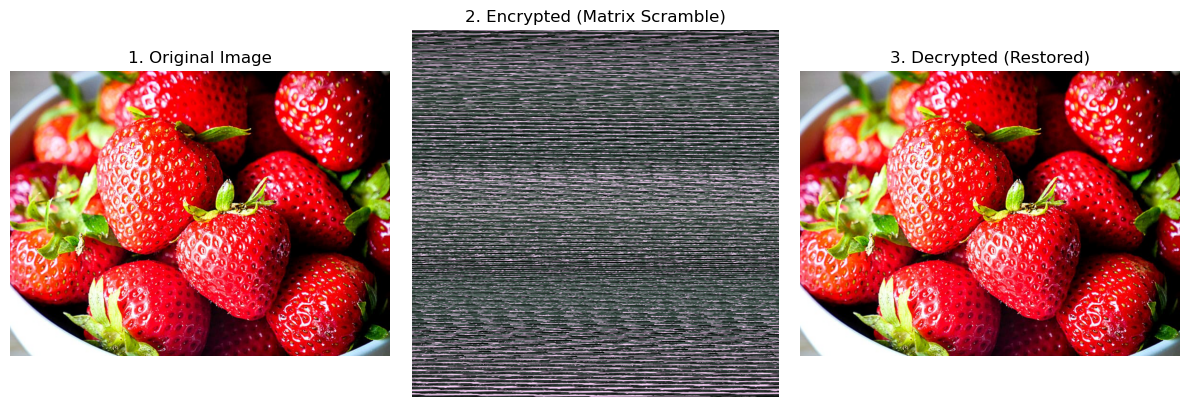

In [12]:
if __name__ == "__main__":
    IMAGE_PATH = "sample.png"  

    try:
        print("Loading image...")
        original_matrix = load_image(IMAGE_PATH)

        print("Generating 3x3 security key...")
        key_matrix = generate_key(size=3)

        print("Encrypting data...")
        encrypted_data, metadata = encrypt_image(original_matrix, key_matrix)

        print("Decrypting data...")
        decrypted_matrix = decrypt_image(encrypted_data, key_matrix, metadata)

        print("Rendering results...")
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("1. Original Image")
        plt.imshow(original_matrix.astype(np.uint8))
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("2. Encrypted (Matrix Scramble)")
        
        enc_flat_vis = encrypted_data.flatten()
       # Calculate dimensions for a 3D color-noise square
        pixels_needed = len(enc_flat_vis) / 3 
        noise_side = int(np.ceil(np.sqrt(pixels_needed)))
        total_data_needed = (noise_side**2) * 3
        pad_size = total_data_needed - len(enc_flat_vis)
        
        # Reshape into (H, W, 3) block and scale floats between 0 and 1 for Matplotlib
        noise_display = np.pad(enc_flat_vis, (0, pad_size)).reshape(noise_side, noise_side, 3)
        noise_display = np.clip(noise_display / np.max(noise_display), 0, 1)
        
        plt.imshow(noise_display)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("3. Decrypted (Restored)")
        plt.imshow(decrypted_matrix)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"ERROR: Could not find '{IMAGE_PATH}'. Please ensure the image is in the same folder as this script.")